# **Introducción a Machine Learning** 🤖📊

## **Objetivos académicos** 🎯
* Conocer estrategias para el tratamiento de datos categóricos  
* Saber cómo seleccionar la cantidad de clusters  
* Conocer la tarea de regresión.  
* Conocer las metricas que permiten evaluar un clasificador.  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

## **Tratamiento de datos**

---

### 📖 Importancia de escalar los datos en modelos de pronóstico  

Muchos algoritmos de Machine Learning, como la regresión logística, KNN o el clustering con K-Means, se basan en cálculos de distancias o en la magnitud de los coeficientes. Si las variables están en escalas muy diferentes (por ejemplo, ingresos en miles frente a edad en años), las de mayor rango dominarán el modelo y distorsionarán los resultados. Escalar los datos —mediante técnicas como **normalización** o **estandarización**— asegura que todas las variables contribuyan de forma equilibrada al entrenamiento, mejora la convergencia de los algoritmos y conduce a predicciones más estables y justas.  


In [2]:


# Creamos un dataset sencillo
data = {
    "edad": [18, 25, 40, 60],
    "ingresos": [1000, 2500, 8000, 20000]
}
df = pd.DataFrame(data)
print("Datos originales:\n", df)

# Inicializamos el scaler
scaler = StandardScaler()

# Ajustamos y transformamos
scaled = scaler.fit_transform(df)

# Convertimos de nuevo a DataFrame
df_scaled = pd.DataFrame(scaled, columns=df.columns)
print("\nDatos escalados:\n", df_scaled)

Datos originales:
    edad  ingresos
0    18      1000
1    25      2500
2    40      8000
3    60     20000

Datos escalados:
        edad  ingresos
0 -1.102532 -0.920381
1 -0.667731 -0.719571
2  0.263987  0.016734
3  1.506277  1.623218


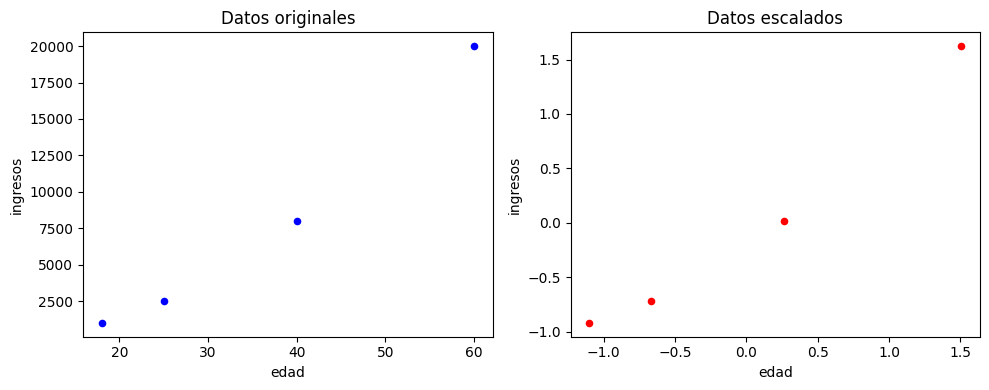

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 fila, 2 columnas

# Scatter izquierda
df.plot.scatter(x='edad', y='ingresos', ax=axes[0], color="blue", title="Datos originales")

# Scatter derecha (puedes cambiar 'otra_variable' por la columna que quieras)
df_scaled.plot.scatter(x='edad', y='ingresos', ax=axes[1], color="red", title="Datos escalados")

plt.tight_layout()
plt.show()

###  Codificación de  variables ⚙️

Muchos modelos de aprendizaje automático no pueden trabajar directamente con variables categóricas (por ejemplo, el país o género de una persona). Estas deben transformarse a una representación numérica mediante un proceso conocido como **codificación**.

Distinguimos tres enfoques comunes:

1. **Label Encoding** – asigna un número entero a cada categoría. Útil para árboles de decisión, pero puede introducir un orden artificial.
2. **One-Hot Encoding** – crea una columna binaria por cada categoría. Es la opción preferida para modelos lineales o redes neuronales.
3. **Ordinal Encoding** – codifica categorías respetando un orden lógico (por ejemplo: Bajo < Medio < Alto).


In [ ]:
# 1. Generamos un dataset base
X, y = make_classification(n_samples=200, n_features=4, random_state=42)
df = pd.DataFrame(X, columns=["feature1", "feature2", "feature3", "feature4"])
df["target"] = y

# 2. Simulamos una variable categórica nominal (sin orden)
df["color"] = np.random.choice(["rojo", "verde", "azul"], size=len(df))

# 3. Simulamos una variable ordinal
df["nivel"] = np.random.choice(["bajo", "medio", "alto"], size=len(df), p=[0.3, 0.4, 0.3])

df.head()

In [ ]:
le = LabelEncoder()
df["color_le"] = le.fit_transform(df["color"])
df[["color", "color_le"]].drop_duplicates()
df.head()

In [ ]:
# OneHotEncoder con drop para evitar colinealidad
ohe = OneHotEncoder(sparse_output=False, drop='first')
color_encoded = ohe.fit_transform(df[["color"]])

# Verificamos cuántas columnas se generaron
print(color_encoded.shape)  # Debe devolver (200, 2)

# Creamos el DataFrame con los nombres correctos
column_names = ohe.get_feature_names_out(["color"])  # Solo devolverá 2 columnas
df_ohe = pd.DataFrame(color_encoded, columns=column_names)

# Concatenamos
df = pd.concat([df, df_ohe], axis=1)
df.head()

In [ ]:
orden_niveles = [["bajo", "medio", "alto"]]  # orden explícito
oe = OrdinalEncoder(categories=orden_niveles)
df["nivel_ord"] = oe.fit_transform(df[["nivel"]])
df[["nivel", "nivel_ord"]].drop_duplicates()
df.head()

### Repasemos conceptos 🧩  


Imagina que quieres entrenar un modelo con la variable “color” (rojo, azul, verde). ¿Cuál sería la mejor forma de representarla numéricamente? 🎯  

* 🔢 Convertir los colores en números consecutivos (rojo=1, azul=2, verde=3)  
* 🟦 Usar **OneHotEncoder** para crear una columna binaria por cada color  
* 🚫 Ignorar la variable porque es categórica  
* ✍️ Convertirla en texto largo  

#### Respuesta correcta ✅  

**🟦 Usar OneHotEncoder para crear una columna binaria por cada color.**  
Así evitamos asignar un orden artificial a categorías que no lo tienen, y el modelo puede interpretar correctamente cada color sin confusiones.  

### Repasemos conceptos 🧩  



Si tienes dos variables, “edad” (en años) y “ingresos” (en miles de dólares), ¿qué podría pasar si no escalas los datos antes de aplicar K-Means? 🤔  

* 📏 El modelo dará más importancia a la variable con valores más grandes  
* 😌 No pasa nada, todas las variables pesan igual  
* 🔄 El número de clusters se elige automáticamente  
* 💥 El algoritmo siempre falla sin escalar  




#### Respuesta correcta ✅  


**📏 El modelo dará más importancia a la variable con valores más grandes.**  
Esto ocurre porque K-Means usa distancias: si una variable tiene valores mucho mayores, dominará el cálculo de los centroides y distorsionará los clusters.  

## **Aprendizaje no supervisado**

---

### **¿Cuántos clúster elegir?**

Elegir el número correcto de clusters es una de las decisiones más importantes al aplicar *K-Means*.  
El **método del codo (Elbow Method)** consiste en graficar la *inercia* (suma de distancias cuadráticas de cada punto a su centroide) para distintos valores de *k*. La inercia siempre disminuye al aumentar *k*, pero llega un momento en que la mejora es mínima y la curva forma un “codo”: ese punto suele ser el número óptimo de clusters, ya que ofrece un balance entre simplicidad y representatividad.  

Otra técnica es el **coeficiente de silhouette**, que mide qué tan bien definido está cada cluster. Su valor va de -1 a 1:  
- Valores cercanos a 1 indican que los puntos están bien agrupados y alejados de otros clusters.  
- Valores cercanos a 0 indican solapamiento entre clusters.  
- Valores negativos sugieren que los puntos podrían estar mal asignados.  

En la práctica, se suele calcular la media del *silhouette score* para distintos valores de *k* y elegir aquel que maximiza esta métrica.  


<center>
  <img src="https://miro.medium.com/v2/resize:fit:670/0*aY163H0kOrBO46S-.png" alt="Elbow" style="max-width:80%; height:auto;"  width="75%">
</center>

In [ ]:
# Dataset sintético
X, y = make_blobs(n_samples=500, centers=4, cluster_std=0.7, random_state=42)

# Valores de k a probar
k_values = range(2, 11)
inertia = []
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertia.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X, model.labels_))

# Gráficas comparativas
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Método del codo
ax[0].plot(k_values, inertia, marker='o')
ax[0].set_title("Método del codo")
ax[0].set_xlabel("Número de clusters (k)")
ax[0].set_ylabel("Inercia")

# Método de silhouette
ax[1].plot(k_values, silhouette_scores, marker='o', color="green")
ax[1].set_title("Coeficiente de silhouette")
ax[1].set_xlabel("Número de clusters (k)")
ax[1].set_ylabel("Silhouette Score")

plt.show()


## **Aprendizaje supervisado**

---

### 🟢 ¿Qué es una tarea de regresión?



En Machine Learning, una **tarea de regresión** consiste en predecir un **valor numérico continuo**. A diferencia de la clasificación (donde elegimos una categoría como “benigno” o “maligno”), aquí el objetivo es predecir una cantidad: un número real.

---

#### 🍡 Ejemplos del mundo real

* ¿Cuál será el precio de esta vivienda? 🏡  
* ¿Cuántas bicicletas se rentarán mañana? 🚴‍♂️  
* ¿Cuánto ganará este cliente el próximo mes? 💵  
* ¿Qué temperatura habrá la semana que viene? 🌡️

En todos estos casos, no buscamos etiquetar, sino **estimar una cantidad**. Y eso es regresión.

---

#### 🌼 Diferencia clave: clasificación vs regresión

| Tipo de problema | Objetivo                  | Ejemplo                         |
|------------------|---------------------------|----------------------------------|
| Clasificación    | Predecir una categoría    | ¿El tumor es benigno o maligno? |
| Regresión        | Predecir un número real   | ¿Cuánto cuesta una casa?        |

> En resumen: **Clasificación = ¿Qué clase? / Regresión = ¿Cuánto?**


In [ ]:

# 1) Generamos un dataset sintético de regresión
X, y = make_regression(n_samples=100, n_features=1, noise=15, random_state=42)

# 2) Dividimos en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3) Creamos y entrenamos el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# 4) Hacemos predicciones
y_pred = model.predict(X_test)

In [ ]:
# 5) Evaluamos el modelo
print("Coeficiente (pendiente):", model.coef_[0])
print("Intercepto:", model.intercept_)
print("Error cuadrático medio (MSE):", mean_squared_error(y_test, y_pred))


In [ ]:

# 6) Visualizamos
plt.scatter(X, y, color="blue", label="Datos reales")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Recta de regresión")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Ejemplo de regresión lineal con make_regression")
plt.show()

¿Cuál de estas tareas corresponde a un problema de regresión en Machine Learning? 📚  

* 📬 Predecir si un correo es spam o no spam  
* 🏠 Estimar el precio de una casa en función de sus características  
* 🐱🐶 Clasificar imágenes de gatos y perros  
* 🩺 Detectar si un tumor es benigno o maligno  



#### Respuesta correcta ✅  


**🏠 Estimar el precio de una casa en función de sus características.**  
En regresión el objetivo es predecir un valor numérico continuo, mientras que en clasificación buscamos asignar categorías.  

### 📖 **¿Cómo evaluar un clasificador?**  




Al entrenar un modelo de clasificación, no basta con saber qué tan seguido acierta: necesitamos distintas métricas para entender su desempeño en profundidad.  

- **Accuracy** mide la proporción de predicciones correctas sobre el total:

$$ 
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} 
$$  

- **Precision** indica de los casos predichos como positivos, cuántos realmente lo eran:  

$$ 
\text{Precision} = \frac{TP}{TP + FP} 
$$  

- **Recall** (o sensibilidad) mide de todos los positivos reales, cuántos detectó el modelo:  

$$
\text{Recall} = \frac{TP}{TP + FN} 
 $$  

- **F1-score** combina precision y recall en una media armónica, útil cuando las clases están desbalanceadas:  

$$ 
\text{F1} = 2 \cdot \frac{\text {Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} 
$$  

- **Curva ROC** muestra la relación entre la *tasa de verdaderos positivos* ($TPR$) y la *tasa de falsos positivos* ($FPR$) a distintos umbrales de decisión. El **AUC (Área bajo la curva)** resume esta curva en un solo valor, donde 1 representa un modelo perfecto y 0.5 un modelo aleatorio.  

En conjunto, estas métricas permiten evaluar no solo la exactitud del modelo, sino también su capacidad para manejar clases desbalanceadas y su comportamiento frente a diferentes umbrales de decisión.  


<center>
  <img src="https://miro.medium.com/v2/resize:fit:1200/0*9h-FJb3PclpQDVQF.png" alt="IA para educación - Logo" style="max-width:80%; height:auto;"  width="25%">
</center>

In [ ]:
# 1) Generamos un dataset sintético de clasificación binaria
X, y = make_classification(n_samples=500, n_features=5, n_informative=3,
                           n_redundant=0, n_classes=2, random_state=42)

# 2) Dividimos en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3) Entrenamos un clasificador
model = LogisticRegression()
model.fit(X_train, y_train)

# 4) Predicciones
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probabilidades para ROC



In [ ]:
# 5) Métricas
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))



In [ ]:
# 6) Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión")
plt.show()



In [ ]:
# 7) Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()


## Para cerrar 💬🤔

----

1. ¿Qué ventajas y limitaciones observaste entre el aprendizaje supervisado y el no supervisado?  
2. Si tuvieras que aplicar Machine Learning en un problema real de tu interés (salud, deportes, negocios, etc.), ¿qué tipo de aprendizaje y algoritmo escogerías y por qué?  


## 🚀 Para seguir aprendiendo :

---

- 📚 Vuelve a revisar este notebook y trata resolver por tu cuenta el proyecto nuevamente
- 💬 Recuerda que en Discord puedes dejar todos tus comentarios y dudas sobre el contenido del sprint en [Sprint 13](https://discord.com/channels/1081207584104656986/1270074296395497513).
    - 📝 Si tienes preguntas sobre tu proyecto, usa el canal `#project` para recibir ayuda y compartir ideas.
    - 🤝 Aprovecha el espacio de `CoLearning` para aclarar tus dudas junto con otros estudiantes e instructores: [Co-Learning](https://discord.com/channels/1081207584104656986/1197953851391746119).
- 📅 ¿Necesitas ayuda personalizada? Puedes agendar una sesión `1:1` conmigo aquí: [1:1 Roman Castillo](https://scheduler.zoom.us/roman-castillo/1-1-roman-castillo).

- Por último hazme paro y responde la encuesta al final de la sesión, me sirve para poder ayudarte mejor 

¡Sigue practicando y no dudes en pedir apoyo cuando lo necesites! 💪✨